In [2]:
#Decision Tree Optimization
#Tune hyperparameter "Max Depth" 

In [3]:
import pandas as pd 
import numpy as np 
import os
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 

In [15]:
filename = "cell2celltrain.csv"
df = pd.read_csv(filename, header=0)

In [16]:
df.head()

,CustomerID,Churn,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,HomeownershipKnown,BuysViaMailOrder,RespondsToMailOffers,...,Occupation_Crafts,Occupation_Homemaker,Occupation_Other,Occupation_Professional,Occupation_Retired,Occupation_Self,Occupation_Student,Married_False,Married_True,Married_nan
0,3000002,True,False,False,True,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3000010,True,True,False,False,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3000014,False,True,False,False,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3000022,False,False,False,True,False,False,True,True,True,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,3000026,True,False,False,False,False,False,True,True,True,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [17]:
df.shape

(51047, 85)

In [19]:
list(df.loc[:,df.columns != 'Churn'])

['CustomerID',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'HomeownershipKnown',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'OwnsMotorcycle',
 'MadeCallToRetentionTeam',
 'MonthlyRevenue',
 'MonthlyMinutes',
 'TotalRecurringCharge',
 'DirectorAssistedCalls',
 'OverageMinutes',
 'RoamingCalls',
 'PercChangeMinutes',
 'PercChangeRevenues',
 'DroppedCalls',
 'BlockedCalls',
 'UnansweredCalls',
 'CustomerCareCalls',
 'ThreewayCalls',
 'ReceivedCalls',
 'OutboundCalls',
 'InboundCalls',
 'PeakCallsInOut',
 'OffPeakCallsInOut',
 'DroppedBlockedCalls',
 'CallForwardingCalls',
 'CallWaitingCalls',
 'MonthsInService',
 'UniqueSubs',
 'ActiveSubs',
 'Handsets',
 'HandsetModels',
 'CurrentEquipmentDays',
 'AgeHH1',
 'AgeHH2',
 'RetentionCalls',
 'RetentionOffersAccepted',
 'ReferralsMadeBySubscriber',
 'IncomeGroup',
 'AdjustmentsToCr

In [21]:
y = df['Churn']
X = df.drop(columns='Churn')

print("Num of Examples: " + str(X.shape[0]))
print("Num of Features: " + str(X.shape[1]))
print(str(list(X.columns))) 

Num of Examples: 51047
Num of Features: 84
['CustomerID', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'HomeownershipKnown', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRat

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=123)

In [23]:
print(X_train.shape)
print(X_test.shape)


(35732, 84)
(15315, 84)


In [ ]:
def train_test_DT(X_train, X_test, y_train, y_test, leaf, depth, crit='entropy'):
    model = DecisionTreeClassifier(criterion=crit, max_depth=depth, min_samples_leaf=leaf)
    model.fit(X_train, y_train)
    class_label_predictions = model.predict(X_test)
    acc_score = accuracy_score(y_test, class_label_predictions)#True, Predict

    return acc_score

#Criterion: decide how tree measures each split quality
#Depth: Max num of levels 
#Leaf: Min num of training exa allowed in every leaf node

In [27]:
#Compare Hyperparameter Values
#max_depth = 8 VS 32 

max_depth_range = [8,12]
acc = []

for md in max_depth_range:
    score = train_test_DT(X_train, X_test, y_train, y_test, 1, md)
    print("Max Depth=" + str(md) + ", accuracy score: " + str(score))
    acc.append(score)


Max Depth=8, accuracy score: 0.710871694417238
Max Depth=12, accuracy score: 0.6929807378387202


<>:5: SyntaxWarning: invalid escape sequence '\_'
<>:5: SyntaxWarning: invalid escape sequence '\_'
/var/folders/3p/z7301m2x50g0m2zv0lkgh48h0000gn/T/ipykernel_41279/3295665705.py:5: SyntaxWarning: invalid escape sequence '\_'
  plt.title('Test set accuracy of the DT predictions, for $max\_depth\in\{8,12\}$')


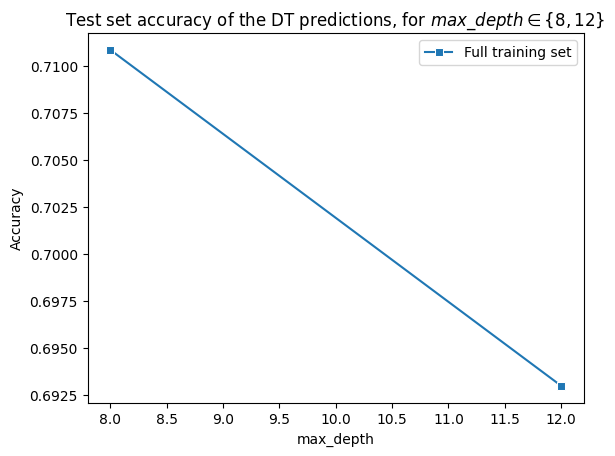

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)#1row,1col,1subplot
p = sns.lineplot(x=max_depth_range, y=acc, marker='s', label='Full training set')

plt.title('Test set accuracy of the DT predictions, for $max\_depth\in\{8,12\}$') 
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
plt.show()

In [39]:
max_depth_range = [2**i for i in range(6)]
acc = []

print("Accuracy scores: ")
for md in max_depth_range:
    score = train_test_DT(X_train, X_test, y_train, y_test, 1, md)
    print("Max Depth= " + str(md) + ", accuracy score" + str(score))
    acc.append(score)

Accuracy scores: 
Max Depth= 1, accuracy score0.7107411034933072
Max Depth= 2, accuracy score0.7107411034933072
Max Depth= 4, accuracy score0.7143323539014038
Max Depth= 8, accuracy score0.710545217107411
Max Depth= 16, accuracy score0.6613124387855044
Max Depth= 32, accuracy score0.6161279791054521


<>:6: SyntaxWarning: invalid escape sequence '\_'
<>:6: SyntaxWarning: invalid escape sequence '\_'
/var/folders/3p/z7301m2x50g0m2zv0lkgh48h0000gn/T/ipykernel_41279/3431291787.py:6: SyntaxWarning: invalid escape sequence '\_'
  plt.title("Test set accuracy of the DT predictions, for $max\_depth\in(2^0, 2^{5})$")


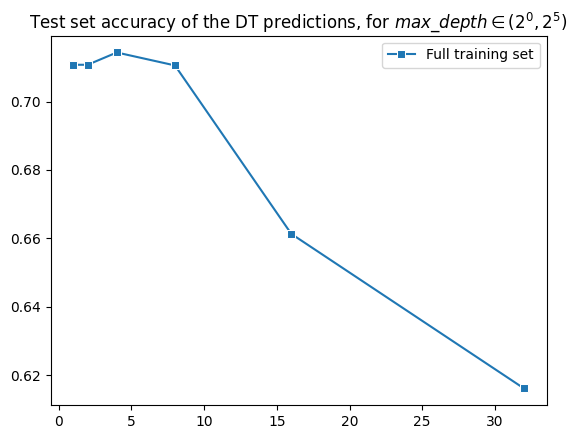

In [40]:
x = max_depth_range

fig = plt.figure()
p_grid = sns.lineplot(x=x, y=acc, marker='s', label="Full training set")

plt.title("Test set accuracy of the DT predictions, for $max\_depth\in(2^0, 2^{5})$")
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
plt.show()


In [42]:
#Identify Most Important Features 
model = DecisionTreeClassifier(min_samples_leaf=100, max_depth=20, criterion="entropy")
model.fit(X_train, y_train)

fi = model.feature_importances_
fi[:5]

array([0.05166069, 0.00161232, 0.01458367, 0.01012555, 0.        ])

In [43]:
names_sorted = [x for _, x in sorted(zip(fi, X_train.columns.values), reverse = True)]

Text(0, 0.5, 'Normalized importance')

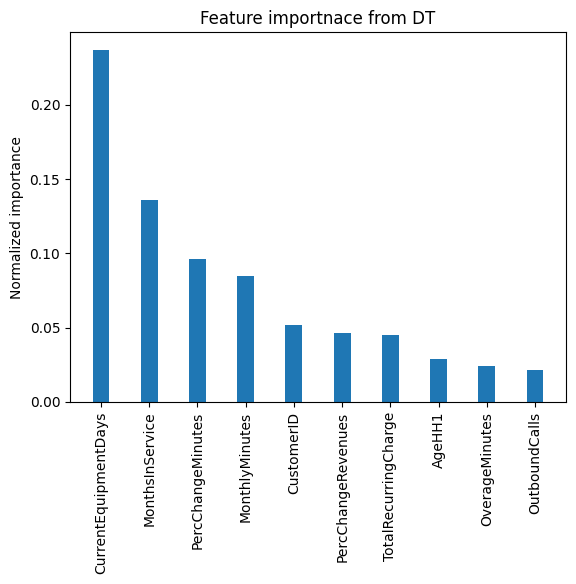

In [ ]:
fig, ax = plt.subplots()

#ax.bar(x, height, width)
ax.bar(
    np.arange(10), #arr[0-9] positions
    sorted(model.feature_importances_, reverse=True)[:10],
    width=0.35
)
ax.set_xticks(np.arange(10))#set tick position on x axis
ax.set_xticklabels(names_sorted[:10], rotation = 90)
plt.title("Feature importnace from DT")
ax.set_ylabel("Normalized importance")